# Multi-Factor Portfolio Research Framework — Indian Equities
## Notebook 06: Regime Diagnostics

Fits a 3-state Gaussian Hidden Markov Model to NIFTY 50 returns and overlays the baseline
portfolio's realised performance onto the resulting regime timeline. This is a **purely
observational, post-hoc diagnostic** — the HMM is never used for, and never feeds back into,
portfolio construction anywhere in this project.

**Confirmed design decisions for this notebook:**
- **3-state Gaussian HMM** (Bull / Bear / High Volatility) — not 2-state, per the locked design in
  `PROJECT_STATE.md` Section 3.7.
- **Fit on NIFTY 50 returns only, never on portfolio returns.** Features: daily return, rolling
  volatility, and drawdown.
- **Rolling volatility window = 21 trading days** (~1 month), confirmed with the user.
- **Fit over the full available NIFTY history** (`WARMUP_START -> END_DATE`, not just the backtest
  window) for a more robust regime estimate — more history helps the HMM separate regimes — but the
  regime-conditional **performance overlay is restricted to the backtest window**, since that's the
  only period portfolio returns actually exist for. This is a disclosed choice, not a locked
  convention.
- **Regime-conditional performance overlay is baseline-only** (Quarterly + EqualWeight), confirmed
  with the user, consistent with NB05's sector-weight-over-time and rotation analyses which made the
  same baseline-only choice for the same reason (six full combinations would be six times the work
  for a diagnostic that's illustrative, not decision-relevant).
- **State labels (Bull / Bear / High Volatility) are assigned post-hoc from the fitted state
  statistics**, not assumed by state index order (`hmmlearn` does not guarantee any particular
  ordering of states) — the exact labeling rule is disclosed in Cell 6, and the underlying per-state
  statistics are printed so the labeling can be checked, not taken on faith.
- **Regime persistence is explicitly reported** (transition matrix, expected regime duration, count
  of short-lived state runs) because 3-state HMMs are known to sometimes produce unstable or
  short-lived states — this is disclosed as a limitation of the modeling choice, not hidden.
- **No starting capital, no "portfolio value" language**, per the standing project-wide rule.
- **Scope boundary:** this notebook is the last in the project — it does not feed back into, revise,
  or re-run any portfolio construction or backtest logic from NB01-05.


### Cell 1 — Install Packages

In [1]:
!pip install pandas numpy matplotlib scipy hmmlearn --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\vidya\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


### Cell 2 — Configuration & Dark Theme

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import textwrap
import warnings
import os
import json

warnings.filterwarnings('ignore')

from hmmlearn import hmm

BASE_DIR   = '.'
DATA_DIR   = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR = os.path.join(BASE_DIR, 'output')
os.makedirs(DATA_DIR,   exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
#  ▶▶  REGIME DIAGNOSTICS PARAMETERS (locked / confirmed)  ◀◀
# ══════════════════════════════════════════════════════════════════════════════
ANN_FACTOR        = 252
RISK_FREE_RATE    = 0.0            # locked, project-wide
N_REGIME_STATES   = 3              # confirmed: 3-state, not 2-state
VOL_WINDOW        = 21             # confirmed with the user: ~1 month rolling volatility
BASELINE_COMBO    = ('Quarterly', 'EqualWeight')   # confirmed: overlay is baseline-only
HMM_RANDOM_STATE  = 42
HMM_N_ITER        = 1000
SHORT_RUN_THRESHOLD_DAYS = 3       # a regime run this short or shorter is flagged as unstable

# -- Visual style: identical to Notebooks 01-05, reused across the whole project --
DARK_BG    = '#0D0D0D'
PANEL_BG   = '#1A1A1A'
COLORS     = ['#29B6F6', '#FF7043', '#66BB6A', '#CE93D8', '#FFB300',
              '#F48FB1', '#80DEEA', '#FFCC02', '#A5D6A7', '#EF9A9A']
ACCENT     = '#00FF88'
ACCENT2    = '#FF5252'
GRID_COLOR = '#2A2A2A'
TEXT_COLOR = '#E0E0E0'
REGIME_COLORS = {'Bull': ACCENT, 'Bear': ACCENT2, 'High Volatility': '#FFB300'}

plt.rcParams.update({
    'figure.facecolor': DARK_BG,   'axes.facecolor':  DARK_BG,
    'savefig.facecolor': DARK_BG,
    'axes.edgecolor':   GRID_COLOR, 'axes.labelcolor': TEXT_COLOR,
    'xtick.color':      TEXT_COLOR, 'ytick.color':     TEXT_COLOR,
    'text.color':       TEXT_COLOR, 'grid.color':      GRID_COLOR,
    'grid.linestyle':   '--',       'grid.alpha':      0.4,
    'font.family':      'monospace',
    'legend.facecolor': PANEL_BG,  'legend.edgecolor': GRID_COLOR,
})


def _wrap_cell_text(value, max_chars):
    """Wraps a cell's text onto multiple lines (on whitespace) so no single line exceeds
    max_chars -- this is what prevents matplotlib table cells from overflowing into (and visually
    overlapping with) their neighbours."""
    s = str(value)
    if len(s) <= max_chars:
        return s
    wrapped = textwrap.wrap(s, width=max_chars, break_long_words=False, break_on_hyphens=False)
    return '\n'.join(wrapped) if wrapped else s


def _prepare_table_layout(df, max_col_chars=26, min_col_frac=0.055):
    """Shared layout engine for every dark-themed table in this notebook: wraps long cell/header
    text, derives column widths from the longest post-wrap line in each column, and derives
    NORMALISED (sum-to-1) row-height fractions from how many wrapped lines each row needs."""
    n_rows, n_cols = df.shape
    wrapped_cols = [_wrap_cell_text(c, max_col_chars) for c in df.columns]
    wrapped_values = np.empty((n_rows, n_cols), dtype=object)
    for r in range(n_rows):
        for c in range(n_cols):
            wrapped_values[r, c] = _wrap_cell_text(df.iloc[r, c], max_col_chars)

    def _max_line_len(text):
        return max((len(line) for line in str(text).split('\n')), default=1)

    raw_widths = []
    for c in range(n_cols):
        col_lines = [_max_line_len(wrapped_cols[c])] + [_max_line_len(wrapped_values[r, c]) for r in range(n_rows)]
        raw_widths.append(max(col_lines))
    total = sum(raw_widths) if sum(raw_widths) > 0 else 1
    col_widths = [max(w / total, min_col_frac) for w in raw_widths]
    w_sum = sum(col_widths)
    col_widths = [w / w_sum for w in col_widths]

    def _n_lines(text):
        return str(text).count('\n') + 1

    header_lines = max(_n_lines(c) for c in wrapped_cols)
    row_line_counts = [max(_n_lines(wrapped_values[r, c]) for c in range(n_cols)) for r in range(n_rows)]
    total_line_units = header_lines + sum(row_line_counts)

    header_height_frac = header_lines / total_line_units
    row_height_fracs = [n / total_line_units for n in row_line_counts]

    return {
        'wrapped_values': wrapped_values, 'wrapped_cols': wrapped_cols, 'col_widths': col_widths,
        'header_lines': header_lines, 'row_line_counts': row_line_counts,
        'total_line_units': total_line_units,
        'header_height_frac': header_height_frac, 'row_height_fracs': row_height_fracs,
    }


def render_dark_table(df, title, filename, col_widths=None, figsize=None, header_color=ACCENT,
                       max_col_chars=26, font_size=9.5):
    df_str = df.astype(str)
    layout = _prepare_table_layout(df_str, max_col_chars=max_col_chars)
    if col_widths is None:
        col_widths = layout['col_widths']

    n_rows, n_cols = df.shape
    PER_LINE_INCH = 0.34
    TITLE_PAD_INCH = 1.5
    fig_w = figsize[0] if figsize else max(9, 1.15 * n_cols + 0.09 * max(sum(len(str(c)) for c in df.columns), 40))
    fig_h = figsize[1] if figsize else layout['total_line_units'] * PER_LINE_INCH + TITLE_PAD_INCH

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis('off')

    tbl = ax.table(cellText=layout['wrapped_values'], colLabels=layout['wrapped_cols'], cellLoc='center',
                   loc='center', colWidths=col_widths)
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(font_size)

    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor(GRID_COLOR)
        cell.set_linewidth(0.6)
        if row == 0:
            cell.set_height(layout['header_height_frac'])
            cell.set_facecolor(header_color)
            cell.set_text_props(weight='bold', color=DARK_BG, fontsize=font_size + 0.5)
        else:
            cell.set_height(layout['row_height_fracs'][row - 1])
            cell.set_facecolor(PANEL_BG if (row - 1) % 2 == 0 else DARK_BG)
            cell.set_text_props(color=TEXT_COLOR)

    ax.set_title(title, fontsize=13, fontweight='bold', color=TEXT_COLOR, pad=16)
    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
    plt.show()
    print(f'Saved -> {path}')
    return path


print('Configuration loaded (Notebook 06 -- Regime Diagnostics).')
print(f'  HMM states           : {N_REGIME_STATES} (Bull / Bear / High Volatility)')
print(f'  Volatility window    : {VOL_WINDOW} trading days')
print(f'  Baseline combination : {BASELINE_COMBO[0]} + {BASELINE_COMBO[1]}')


Configuration loaded (Notebook 06 -- Regime Diagnostics).
  HMM states           : 3 (Bull / Bear / High Volatility)
  Volatility window    : 21 trading days
  Baseline combination : Quarterly + EqualWeight


### Cell 3 — Load Notebook 01 / 04 Outputs

In [3]:
benchmark_nifty50 = pd.read_csv(os.path.join(DATA_DIR, 'benchmark_nifty50.csv'),
                                 index_col=0, parse_dates=True).iloc[:, 0]
backtest_daily_returns = pd.read_csv(
    os.path.join(DATA_DIR, 'backtest_daily_returns.csv'), parse_dates=['date']
)

with open(os.path.join(DATA_DIR, 'study_window.json'), 'r') as f:
    _sw = json.load(f)
WARMUP_START   = _sw.get('warmup_start',   '2015-07-01')
BACKTEST_START = _sw.get('backtest_start', '2018-07-01')
END_DATE       = _sw.get('end_date',       benchmark_nifty50.index[-1].strftime('%Y-%m-%d'))

baseline_freq, baseline_scheme = BASELINE_COMBO
baseline_daily_returns = backtest_daily_returns[
    (backtest_daily_returns['frequency'] == baseline_freq) &
    (backtest_daily_returns['weighting_scheme'] == baseline_scheme)
].set_index('date').sort_index()

print(f'NIFTY 50 price history (full)     : {benchmark_nifty50.shape}  '
      f'({benchmark_nifty50.index[0].date()} -> {benchmark_nifty50.index[-1].date()})')
print(f'Baseline combination daily returns : {baseline_daily_returns.shape}  '
      f'({baseline_freq} + {baseline_scheme})')
print(f'Study window                       : warm-up {WARMUP_START} / backtest {BACKTEST_START} -> {END_DATE}')


NIFTY 50 price history (full)     : (2718,)  (2015-07-01 -> 2026-07-15)
Baseline combination daily returns : (1964, 4)  (Quarterly + EqualWeight)
Study window                       : warm-up 2015-07-01 / backtest 2018-07-01 -> 2026-07-16


### Cell 4 — Feature Engineering (NIFTY 50 Only)

Three features, computed over the **full available NIFTY 50 price history** (not just the backtest
window, per the disclosed fit-on-more-history choice above): daily return, rolling volatility
(21-trading-day window, confirmed), and drawdown from the running peak. The first `VOL_WINDOW - 1`
days have no rolling volatility yet and are dropped explicitly (never silently kept as NaN). Features
are then **standardised (z-scored)** before fitting -- the three features live on very different
scales (daily return ~0.001, drawdown can be -0.3 or lower), and an unstandardised fit would let the
largest-scale feature dominate the HMM's emission distributions.

In [4]:
nifty_returns_full = benchmark_nifty50.pct_change().dropna()
nifty_cum_full = (1.0 + nifty_returns_full).cumprod()
nifty_rolling_vol_full = nifty_returns_full.rolling(VOL_WINDOW).std()
nifty_drawdown_full = nifty_cum_full / nifty_cum_full.cummax() - 1.0

features_df = pd.DataFrame({
    'return': nifty_returns_full,
    'volatility': nifty_rolling_vol_full,
    'drawdown': nifty_drawdown_full,
}).dropna()

n_dropped = len(nifty_returns_full) - len(features_df)
print(f'Full NIFTY return series length      : {len(nifty_returns_full)}')
print(f'Rows dropped (rolling-vol warm-up)    : {n_dropped}  (first {VOL_WINDOW - 1} days, as expected)')
print(f'Feature matrix for HMM fitting        : {features_df.shape}')

feature_means = features_df.mean()
feature_stds = features_df.std(ddof=0)
features_std = (features_df - feature_means) / feature_stds

print()
print('Feature summary (raw, pre-standardisation):')
print(features_df.describe().round(5).to_string())


Full NIFTY return series length      : 2717
Rows dropped (rolling-vol warm-up)    : 20  (first 20 days, as expected)
Feature matrix for HMM fitting        : (2697, 3)

Feature summary (raw, pre-standardisation):
           return  volatility    drawdown
count  2697.00000  2697.00000  2697.00000
mean      0.00044     0.00887    -0.05254
std       0.01026     0.00514     0.05264
min      -0.12980     0.00320    -0.38440
25%      -0.00433     0.00606    -0.08098
50%       0.00064     0.00765    -0.03963
75%       0.00586     0.00991    -0.01145
max       0.08763     0.05536     0.00000


### Cell 5 — Fit 3-State Gaussian HMM (NIFTY 50 Returns Only)

`covariance_type='diag'` (each state's three features have independent variances, no
cross-covariance terms) is used deliberately -- it is the simpler, less overfitting-prone choice for
a 3-feature, 3-state model on a few thousand observations, disclosed here rather than silently
defaulting to `'full'`. `random_state` is fixed for reproducibility, since EM-based HMM fitting is
otherwise sensitive to its random initialisation.

In [5]:
hmm_model = hmm.GaussianHMM(
    n_components=N_REGIME_STATES, covariance_type='diag', n_iter=HMM_N_ITER,
    random_state=HMM_RANDOM_STATE, tol=1e-4,
)
hmm_model.fit(features_std.to_numpy())

converged = hmm_model.monitor_.converged
print(f'HMM fit converged : {converged}  (after up to {HMM_N_ITER} EM iterations)')
if not converged:
    print('WARNING: the HMM did not report convergence -- treat the fitted regimes with extra caution.')

decoded_states = hmm_model.predict(features_std.to_numpy())
features_df = features_df.copy()
features_df['state'] = decoded_states

print(f'Decoded state sequence length: {len(decoded_states)}')
print(f'State counts (raw index, before labeling): {pd.Series(decoded_states).value_counts().sort_index().to_dict()}')


HMM fit converged : True  (after up to 1000 EM iterations)
Decoded state sequence length: 2697
State counts (raw index, before labeling): {0: 1292, 1: 1023, 2: 382}


### Cell 6 — Label States (Disclosed Heuristic)

**State labels are assigned post-estimation.** The HMM itself is unsupervised and has no knowledge
of market states -- it only sees the three standardised features and finds statistically distinct
clusters of days. Labels are based on each state's mean return, volatility, and drawdown, computed
*after* fitting, not supplied to the model in any way.

`hmmlearn` does not guarantee any particular ordering of fitted states, so state indices must be
mapped to Bull / Bear / High Volatility from their **actual fitted statistics**, not assumed. The
rule used here, in order:

1. Compute each state's mean return, mean volatility, and mean drawdown from the days actually
   assigned to it (post-hoc, from the decoded sequence -- not from the model's internal standardised
   `means_`, which are harder to interpret directly).
2. **High Volatility** = whichever state has the highest mean volatility of the three.
3. Of the two remaining states, **Bull** = higher mean return, **Bear** = lower mean return.

Volatility is checked first because "high volatility" is this project's explicit third regime label
(not "Bull"/"Bear" with some in-between state) -- if a state has both the lowest return *and* the
highest volatility, it will end up labeled High Volatility, not Bear, which is disclosed here as the
deliberate tie-breaking priority rather than left implicit.

In [6]:
state_stats = features_df.groupby('state')[['return', 'volatility', 'drawdown']].mean()
state_stats['n_days'] = features_df.groupby('state').size()
state_stats['pct_days'] = (state_stats['n_days'] / len(features_df) * 100.0).round(2)

print('Per-state statistics (raw units, from actual assigned days):')
print(state_stats.round(5).to_string())
print()

high_vol_state = state_stats['volatility'].idxmax()
remaining_states = [s for s in state_stats.index if s != high_vol_state]
bull_state = state_stats.loc[remaining_states, 'return'].idxmax()
bear_state = [s for s in remaining_states if s != bull_state][0]

STATE_LABELS = {bull_state: 'Bull', bear_state: 'Bear', high_vol_state: 'High Volatility'}
print('State label assignment:')
for state_idx, label in sorted(STATE_LABELS.items()):
    row = state_stats.loc[state_idx]
    print(f'  State {state_idx} -> {label:15s}  '
          f'(mean return={row["return"]:+.5f}, mean vol={row["volatility"]:.5f}, '
          f'mean drawdown={row["drawdown"]:+.4f}, {row["n_days"]:.0f} days / {row["pct_days"]:.1f}%)')

features_df['regime'] = features_df['state'].map(STATE_LABELS)


Per-state statistics (raw units, from actual assigned days):
        return  volatility  drawdown  n_days  pct_days
state                                                 
0      0.00001     0.00875  -0.06459    1292     47.91
1      0.00090     0.00582  -0.01259    1023     37.93
2      0.00070     0.01744  -0.11873     382     14.16

State label assignment:
  State 0 -> Bear             (mean return=+0.00001, mean vol=0.00875, mean drawdown=-0.0646, 1292 days / 47.9%)
  State 1 -> Bull             (mean return=+0.00090, mean vol=0.00582, mean drawdown=-0.0126, 1023 days / 37.9%)
  State 2 -> High Volatility  (mean return=+0.00070, mean vol=0.01744, mean drawdown=-0.1187, 382 days / 14.2%)


### Cell 7 — Regime Timeline, Transition Matrix & Persistence Diagnostics

3-state HMMs can produce unstable or short-lived states -- this is disclosed explicitly via the
transition matrix, each regime's expected duration (`1 / (1 - self-transition probability)`), and a
count of very short regime "runs" (`SHORT_RUN_THRESHOLD_DAYS` days or fewer), rather than only
reporting the headline regime timeline and leaving persistence unexamined.

In [7]:
transmat_df = pd.DataFrame(
    hmm_model.transmat_, index=[STATE_LABELS[i] for i in range(N_REGIME_STATES)],
    columns=[STATE_LABELS[i] for i in range(N_REGIME_STATES)],
)
print('Transition matrix (row = from, column = to):')
print(transmat_df.round(4).to_string())
print()

expected_duration = {}
for i in range(N_REGIME_STATES):
    p_self = hmm_model.transmat_[i, i]
    expected_duration[STATE_LABELS[i]] = (1.0 / (1.0 - p_self)) if p_self < 1.0 else np.inf
print('Expected regime duration (trading days), from self-transition probability:')
for label, dur in expected_duration.items():
    print(f'  {label:15s}: {dur:.1f} days')
print()

# Identify contiguous regime "runs" for persistence diagnostics
regime_series = features_df['regime']
run_id = (regime_series != regime_series.shift()).cumsum()
run_lengths = regime_series.groupby(run_id).size()
run_labels = regime_series.groupby(run_id).first()
runs_df = pd.DataFrame({'regime': run_labels.values, 'length_days': run_lengths.values})

n_short_runs = int((runs_df['length_days'] <= SHORT_RUN_THRESHOLD_DAYS).sum())
print(f'Total regime runs (contiguous stretches of the same state): {len(runs_df)}')
print(f'Runs of {SHORT_RUN_THRESHOLD_DAYS} days or fewer (flagged as potentially unstable): '
      f'{n_short_runs} ({n_short_runs / len(runs_df) * 100:.1f}% of all runs)')
print()
print('Run-length summary by regime:')
print(runs_df.groupby('regime')['length_days'].agg(['count', 'mean', 'median', 'min', 'max']).round(1).to_string())


Transition matrix (row = from, column = to):
                   Bear    Bull  High Volatility
Bear             0.9771  0.0136           0.0093
Bull             0.0181  0.9809           0.0010
High Volatility  0.0318  0.0022           0.9660

Expected regime duration (trading days), from self-transition probability:
  Bear           : 43.7 days
  Bull           : 52.5 days
  High Volatility: 29.4 days

Total regime runs (contiguous stretches of the same state): 60
Runs of 3 days or fewer (flagged as potentially unstable): 1 (1.7% of all runs)

Run-length summary by regime:
                 count  mean  median  min  max
regime                                        
Bear                29  44.6    32.0    4  127
Bull                19  53.8    34.0    1  252
High Volatility     12  31.8    25.0   13   88


### Chart — Transition Matrix (Colour-Coded)

The same transition matrix printed above, as a heatmap -- probabilities are easier to compare at a
glance by colour than by scanning a grid of numbers, especially for spotting how dominant the
diagonal (self-transition / persistence) is relative to the off-diagonal (switching) probabilities.

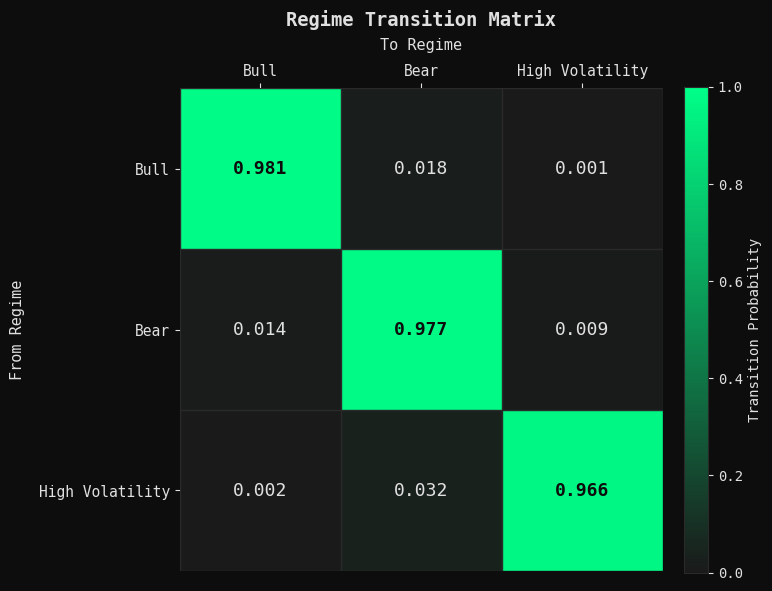

Saved -> .\output\06_transition_matrix_heatmap.png


In [8]:
from matplotlib.colors import LinearSegmentedColormap

transition_cmap = LinearSegmentedColormap.from_list('project_transition', [PANEL_BG, ACCENT])

regime_order = ['Bull', 'Bear', 'High Volatility']
transmat_ordered = transmat_df.loc[regime_order, regime_order]

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(transmat_ordered.values, cmap=transition_cmap, vmin=0, vmax=1, aspect='equal')

ax.set_xticks(range(len(regime_order)))
ax.set_yticks(range(len(regime_order)))
ax.set_xticklabels(regime_order, fontsize=10.5)
ax.set_yticklabels(regime_order, fontsize=10.5)
ax.set_xlabel('To Regime', fontsize=11, labelpad=10)
ax.set_ylabel('From Regime', fontsize=11, labelpad=10)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

for i in range(len(regime_order)):
    for j in range(len(regime_order)):
        val = transmat_ordered.values[i, j]
        text_color = DARK_BG if val > 0.5 else TEXT_COLOR
        weight = 'bold' if i == j else 'normal'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', color=text_color,
                fontsize=13, fontweight=weight)

for i in range(len(regime_order) + 1):
    ax.axhline(i - 0.5, color=GRID_COLOR, linewidth=1.0)
    ax.axvline(i - 0.5, color=GRID_COLOR, linewidth=1.0)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Transition Probability', color=TEXT_COLOR, fontsize=10)
cbar.ax.yaxis.set_tick_params(color=TEXT_COLOR)
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color=TEXT_COLOR)
cbar.outline.set_edgecolor(GRID_COLOR)

ax.set_title('Regime Transition Matrix', fontsize=13.5, fontweight='bold', color=TEXT_COLOR, pad=45)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '06_transition_matrix_heatmap.png')
plt.savefig(path, dpi=160, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')


### Cell 8 — Hand-Computed Unit Test: Regime-Conditional Aggregation

The HMM fit itself is stochastic and can't be hand-verified the same way a deterministic formula can
-- but the **aggregation logic** used later (mean/vol/Sharpe of returns, grouped by regime label) is
completely deterministic and gets the same hand-computed-unit-test treatment as every other
numerically consequential piece of this project (per the standing testing discipline).

In [9]:
# Tiny hand-labeled example: 6 days, 3 in 'Bull', 3 in 'Bear'
test_returns = pd.Series([0.02, 0.01, 0.03, -0.02, -0.01, -0.03])
test_regimes = pd.Series(['Bull', 'Bull', 'Bull', 'Bear', 'Bear', 'Bear'])

test_grouped = test_returns.groupby(test_regimes)

expected_bull_mean = (0.02 + 0.01 + 0.03) / 3
expected_bear_mean = (-0.02 + -0.01 + -0.03) / 3
assert abs(test_grouped.mean()['Bull'] - expected_bull_mean) < 1e-12, 'Bull mean mismatch'
assert abs(test_grouped.mean()['Bear'] - expected_bear_mean) < 1e-12, 'Bear mean mismatch'

expected_bull_ann_return = expected_bull_mean * ANN_FACTOR
expected_bull_ann_vol = test_returns[test_regimes == 'Bull'].std(ddof=1) * np.sqrt(ANN_FACTOR)
expected_bull_sharpe = expected_bull_ann_return / expected_bull_ann_vol

computed_bull_ann_return = test_grouped.mean()['Bull'] * ANN_FACTOR
computed_bull_ann_vol = test_grouped.std(ddof=1)['Bull'] * np.sqrt(ANN_FACTOR)
computed_bull_sharpe = computed_bull_ann_return / computed_bull_ann_vol

assert abs(computed_bull_ann_return - expected_bull_ann_return) < 1e-10, 'Annualised return mismatch'
assert abs(computed_bull_ann_vol - expected_bull_ann_vol) < 1e-10, 'Annualised vol mismatch'
assert abs(computed_bull_sharpe - expected_bull_sharpe) < 1e-10, 'Sharpe mismatch'

print('Test PASSED: regime-conditional mean / annualised vol / Sharpe aggregation matches '
      'hand-computed values on a tiny 6-day, 2-regime example.')


Test PASSED: regime-conditional mean / annualised vol / Sharpe aggregation matches hand-computed values on a tiny 6-day, 2-regime example.


### Chart 1 — NIFTY 50 Cumulative Return, Shaded by Regime

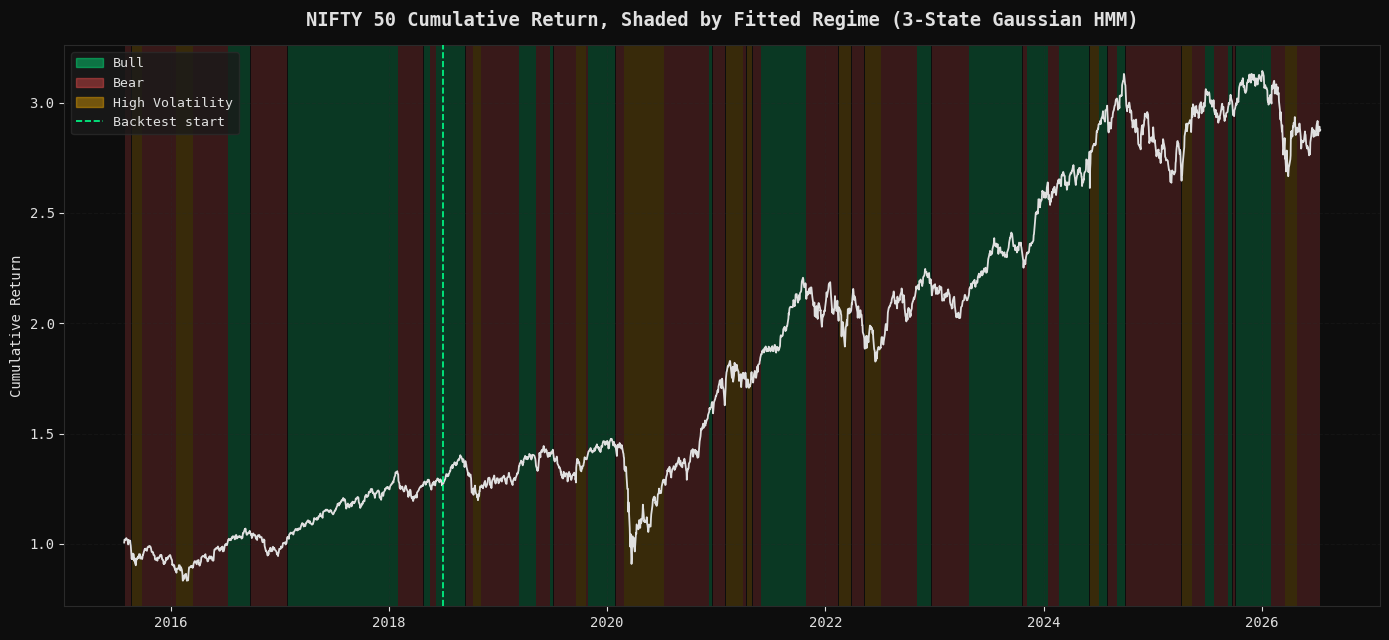

Saved -> .\output\06_regime_timeline.png


In [10]:
fig, ax = plt.subplots(figsize=(14, 6.5))

nifty_cum_plot = (1.0 + features_df['return']).cumprod()
ax.plot(nifty_cum_plot.index, nifty_cum_plot.values, color=TEXT_COLOR, linewidth=1.3, zorder=3)

for run_key, run_group in features_df.groupby(run_id):
    label = run_group['regime'].iloc[0]
    ax.axvspan(run_group.index[0], run_group.index[-1], color=REGIME_COLORS[label], alpha=0.18,
               zorder=1, linewidth=0)

ax.axvline(pd.Timestamp(BACKTEST_START), color=ACCENT, linestyle='--', linewidth=1.2,
           label='Backtest start', zorder=4)

legend_handles = [mpatches.Patch(color=REGIME_COLORS[l], alpha=0.4, label=l) for l in ['Bull', 'Bear', 'High Volatility']]
legend_handles.append(plt.Line2D([0], [0], color=ACCENT, linestyle='--', linewidth=1.2, label='Backtest start'))
ax.legend(handles=legend_handles, fontsize=9.5, loc='upper left', facecolor=PANEL_BG, edgecolor=GRID_COLOR)

ax.set_title('NIFTY 50 Cumulative Return, Shaded by Fitted Regime (3-State Gaussian HMM)',
             fontsize=13.5, fontweight='bold', color=TEXT_COLOR, pad=14)
ax.set_ylabel('Cumulative Return')
ax.grid(True, alpha=0.25)
for spine in ax.spines.values():
    spine.set_color(GRID_COLOR)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '06_regime_timeline.png')
plt.savefig(path, dpi=160, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')


### Cell 10 — Regime-Conditional Performance Overlay (Baseline Combination, Backtest Window Only)

Restricted to the **backtest window** (where the baseline combination's realised returns actually
exist) and to the **baseline combination only** (Quarterly + EqualWeight, confirmed) -- purely
observational: the regime assignment does not change, and nothing here feeds back into portfolio
construction.

In [11]:
regime_bt = features_df.loc[
    (features_df.index >= BACKTEST_START) & (features_df.index <= END_DATE), 'regime'
]

overlay_df = pd.DataFrame({
    'baseline_net_return': baseline_daily_returns['net_return'],
    'nifty_return': features_df['return'],
}).join(regime_bt, how='inner')

perf_rows = []
for label in ['Bull', 'Bear', 'High Volatility']:
    sub = overlay_df[overlay_df['regime'] == label]
    if len(sub) == 0:
        continue
    baseline_ann_return = sub['baseline_net_return'].mean() * ANN_FACTOR
    baseline_ann_vol = sub['baseline_net_return'].std(ddof=1) * np.sqrt(ANN_FACTOR) if len(sub) > 1 else np.nan
    baseline_sharpe = (baseline_ann_return / baseline_ann_vol) if (baseline_ann_vol and not np.isnan(baseline_ann_vol) and baseline_ann_vol > 1e-10) else np.nan

    nifty_ann_return = sub['nifty_return'].mean() * ANN_FACTOR
    nifty_ann_vol = sub['nifty_return'].std(ddof=1) * np.sqrt(ANN_FACTOR) if len(sub) > 1 else np.nan

    perf_rows.append({
        'Regime': label, 'N Days': len(sub),
        'Baseline Ann. Return (%)': baseline_ann_return * 100.0,
        'Baseline Ann. Vol (%)': baseline_ann_vol * 100.0 if not np.isnan(baseline_ann_vol) else np.nan,
        'Baseline Sharpe': baseline_sharpe,
        'NIFTY Ann. Return (%)': nifty_ann_return * 100.0,
        'NIFTY Ann. Vol (%)': nifty_ann_vol * 100.0 if not np.isnan(nifty_ann_vol) else np.nan,
    })

regime_performance_df = pd.DataFrame(perf_rows)
print(f'Backtest-window days with a regime + baseline return: {len(overlay_df)}')
print()
print(regime_performance_df.round(3).to_string(index=False))


Backtest-window days with a regime + baseline return: 1979

         Regime  N Days  Baseline Ann. Return (%)  Baseline Ann. Vol (%)  Baseline Sharpe  NIFTY Ann. Return (%)  NIFTY Ann. Vol (%)
           Bull     690                    46.712                 15.595            2.995                 22.597               9.335
           Bear     970                     9.999                 19.720            0.507                 -0.117              14.339
High Volatility     319                    40.238                 34.488            1.167                 24.832              32.339


### Cell 11 — Summary Table: Regime-Conditional Performance

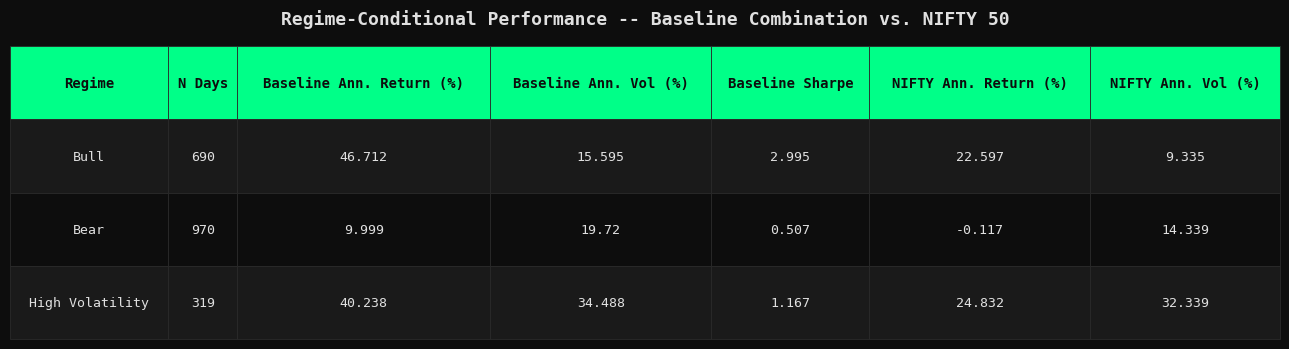

Saved -> .\output\06_regime_performance_table.png


'.\\output\\06_regime_performance_table.png'

In [12]:
render_dark_table(regime_performance_df.round(3),
                   'Regime-Conditional Performance -- Baseline Combination vs. NIFTY 50',
                   '06_regime_performance_table.png', figsize=(13, 3.6))


### Chart — Portfolio Return by Regime, vs. NIFTY 50

The table above in one picture: does the baseline strategy's annualised return beat NIFTY 50 within
each regime, not just on average?

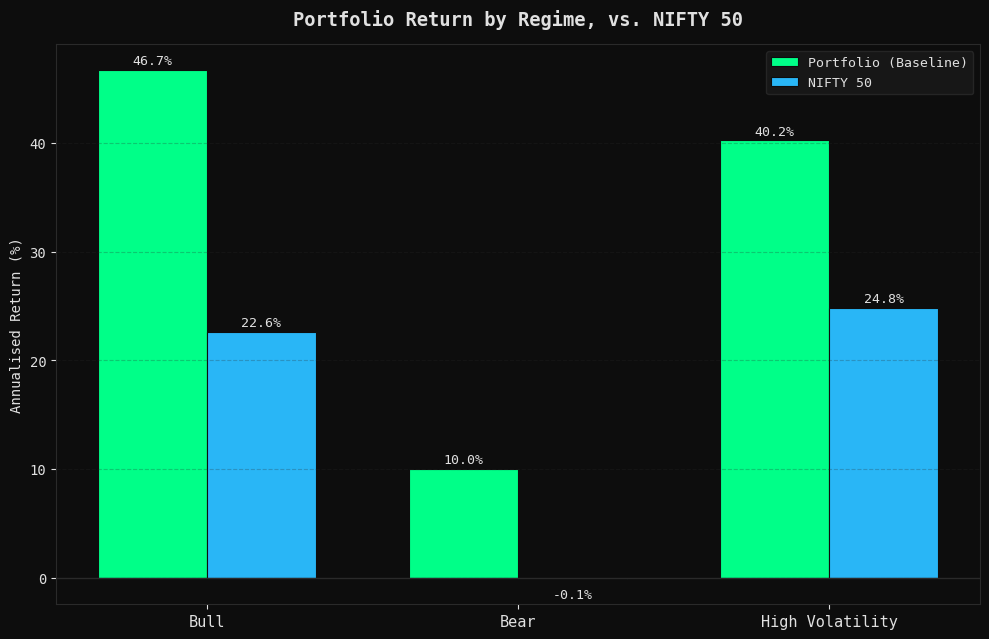

Saved -> .\output\06_portfolio_return_by_regime.png


In [13]:
regime_order_chart = [r for r in ['Bull', 'Bear', 'High Volatility'] if r in regime_performance_df['Regime'].values]
chart_df = regime_performance_df.set_index('Regime').loc[regime_order_chart].reset_index()

fig, ax = plt.subplots(figsize=(10, 6.5))
x = np.arange(len(chart_df))
bar_w = 0.35

bars_port = ax.bar(x - bar_w / 2, chart_df['Baseline Ann. Return (%)'], width=bar_w,
                    color=ACCENT, label='Portfolio (Baseline)', edgecolor=DARK_BG, linewidth=0.8)
bars_nifty = ax.bar(x + bar_w / 2, chart_df['NIFTY Ann. Return (%)'], width=bar_w,
                     color=COLORS[0], label='NIFTY 50', edgecolor=DARK_BG, linewidth=0.8)

for bars in (bars_port, bars_nifty):
    for b in bars:
        h = b.get_height()
        ax.annotate(f'{h:.1f}%', xy=(b.get_x() + b.get_width() / 2, h),
                    xytext=(0, 4 if h >= 0 else -14), textcoords='offset points',
                    ha='center', fontsize=9.5, color=TEXT_COLOR)

ax.axhline(0, color=GRID_COLOR, linewidth=1.0)
ax.set_xticks(x)
ax.set_xticklabels(chart_df['Regime'], fontsize=11)
ax.set_ylabel('Annualised Return (%)')
ax.set_title('Portfolio Return by Regime, vs. NIFTY 50', fontsize=13.5, fontweight='bold',
             color=TEXT_COLOR, pad=14)
ax.legend(fontsize=9.5, facecolor=PANEL_BG, edgecolor=GRID_COLOR)
ax.grid(True, alpha=0.25, axis='y')
for spine in ax.spines.values():
    spine.set_color(GRID_COLOR)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '06_portfolio_return_by_regime.png')
plt.savefig(path, dpi=160, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')


### Limitations (Disclosed)

> **Regime labels are a modeling choice, not ground truth.** A different state count, feature set, or
> rolling-volatility window would very plausibly produce a different regime timeline. The 3-state
> choice, the specific three features (return / volatility / drawdown), and the 21-day volatility
> window are all disclosed, confirmed choices -- not the only reasonable ones.
>
> **3-state HMMs can produce unstable or short-lived states.** Cell 7 reports this directly: the
> transition matrix, each regime's expected duration, and the count of very short (`<=
> SHORT_RUN_THRESHOLD_DAYS`-day) regime runs. A meaningful share of short runs would suggest the
> fitted regimes are noisier than the headline chart alone might suggest -- check that count before
> treating the regime timeline as a clean, stable segmentation.
>
> **The regime-conditional performance overlay is observational only.** It describes how the
> baseline combination happened to perform during days the HMM assigned to each regime -- it is not a
> causal claim, was not used anywhere in portfolio construction, and does not imply the strategy would
> perform this way if regimes were predictable in advance (they were fit with the full benefit of
> hindsight over the entire history).
>
> **The overlay is baseline-only (Quarterly + EqualWeight).** The other 5 combinations were not
> re-examined here, consistent with NB05's precedent of restricting similar illustrative diagnostics
> to the baseline combination.

### Key Findings

Generated directly from the results computed above -- these numbers will change if the notebook is
re-run on updated data; nothing here is a fixed, hardcoded claim.

In [14]:
n_regimes_present = len(regime_performance_df)
best_regime_row = regime_performance_df.loc[regime_performance_df['Baseline Sharpe'].idxmax()]
outperform_count = int(
    (regime_performance_df['Baseline Ann. Return (%)'] > regime_performance_df['NIFTY Ann. Return (%)']).sum()
)
short_run_share_pct = n_short_runs / len(runs_df) * 100.0
duration_values = list(expected_duration.values())
duration_min, duration_max = min(duration_values), max(duration_values)

findings = []

findings.append(
    f'The HMM converged successfully ({converged}) and identified {N_REGIME_STATES} regimes '
    f'({", ".join(regime_order)}) across {len(features_df)} trading days of NIFTY 50 history.'
)

findings.append(
    f'The {best_regime_row["Regime"]} regime exhibited the highest baseline portfolio Sharpe '
    f'({best_regime_row["Baseline Sharpe"]:.2f}) and annualised return '
    f'({best_regime_row["Baseline Ann. Return (%)"]:+.1f}%) among the {n_regimes_present} regime(s) '
    f'present during the backtest window.'
)

if outperform_count == n_regimes_present:
    findings.append(
        f'The baseline strategy outperformed NIFTY 50 in all {n_regimes_present} regimes present '
        f'during the backtest window.'
    )
else:
    underperform_regimes = regime_performance_df.loc[
        regime_performance_df['Baseline Ann. Return (%)'] <= regime_performance_df['NIFTY Ann. Return (%)'],
        'Regime'
    ].tolist()
    findings.append(
        f'The baseline strategy outperformed NIFTY 50 in {outperform_count} of {n_regimes_present} regimes '
        f'present during the backtest window, underperforming in: {", ".join(underperform_regimes)}.'
    )

duration_note = f'Average regime durations ranged from ~{duration_min:.0f} to ~{duration_max:.0f} trading days'
if short_run_share_pct < 15.0:
    duration_note += (', with a low share of short-lived runs -- indicating reasonably stable regime '
                       'identification rather than noisy day-to-day switching.')
else:
    duration_note += (f', but {short_run_share_pct:.0f}% of all regime runs lasted '
                       f'{SHORT_RUN_THRESHOLD_DAYS} days or fewer -- some caution is warranted about '
                       f'regime stability.')
findings.append(duration_note)

print('=' * 70)
print('KEY FINDINGS')
print('=' * 70)
for f in findings:
    print(f'  - {f}')


KEY FINDINGS
  - The HMM converged successfully (True) and identified 3 regimes (Bull, Bear, High Volatility) across 2697 trading days of NIFTY 50 history.
  - The Bull regime exhibited the highest baseline portfolio Sharpe (3.00) and annualised return (+46.7%) among the 3 regime(s) present during the backtest window.
  - The baseline strategy outperformed NIFTY 50 in all 3 regimes present during the backtest window.
  - Average regime durations ranged from ~29 to ~52 trading days, with a low share of short-lived runs -- indicating reasonably stable regime identification rather than noisy day-to-day switching.


### Cell 13 — Save All Regime Diagnostics Outputs to `data/`

In [15]:
regime_timeline_df = features_df[['return', 'volatility', 'drawdown', 'state', 'regime']].reset_index()
regime_timeline_df = regime_timeline_df.rename(columns={'index': 'date'})
regime_timeline_df.to_csv(os.path.join(DATA_DIR, 'regime_timeline.csv'), index=False)

transmat_df.to_csv(os.path.join(DATA_DIR, 'regime_transition_matrix.csv'))
regime_performance_df.to_csv(os.path.join(DATA_DIR, 'regime_performance_summary.csv'), index=False)
runs_df.to_csv(os.path.join(DATA_DIR, 'regime_runs.csv'), index=False)

print('Saved to data/:')
for f in ['regime_timeline.csv', 'regime_transition_matrix.csv', 'regime_performance_summary.csv',
          'regime_runs.csv']:
    print(f'  {f}')

print()
print('=' * 60)
print('NOTEBOOK 06 -- COMPLETE')
print('=' * 60)
print(f'  HMM states                 : {N_REGIME_STATES} (Bull / Bear / High Volatility)')
print(f'  Fit converged              : {converged}')
print(f'  Total regime runs          : {len(runs_df)}  ({n_short_runs} short-lived, '
      f'<= {SHORT_RUN_THRESHOLD_DAYS} days)')
print(f'  Baseline combination       : {baseline_freq} + {baseline_scheme}')
print()
print('  Charts in output/:')
for f in ['06_regime_timeline.png', '06_regime_performance_table.png']:
    print(f'    {f}')
print()
print('  This is the final notebook in the 6-notebook project pipeline.')


Saved to data/:
  regime_timeline.csv
  regime_transition_matrix.csv
  regime_performance_summary.csv
  regime_runs.csv

NOTEBOOK 06 -- COMPLETE
  HMM states                 : 3 (Bull / Bear / High Volatility)
  Fit converged              : True
  Total regime runs          : 60  (1 short-lived, <= 3 days)
  Baseline combination       : Quarterly + EqualWeight

  Charts in output/:
    06_regime_timeline.png
    06_regime_performance_table.png

  This is the final notebook in the 6-notebook project pipeline.


## Notebook Summary

| Cell | Action | Result |
|---|---|---|
| 1 | Install packages | pandas, numpy, matplotlib, scipy, hmmlearn |
| 2 | Configuration & dark theme | HMM params, vol window, baseline combo, `render_dark_table` |
| 3 | Load NB01/NB04 outputs | NIFTY 50 price history, baseline combination daily returns |
| 4 | Feature engineering | Daily return, 21d rolling volatility, drawdown; standardised |
| 5 | Fit 3-state Gaussian HMM | `covariance_type='diag'`, fixed random state, convergence checked |
| 6 | Label states | Bull / Bear / High Volatility, from actual fitted per-state statistics; clarifies labels are post-estimation and the HMM is unsupervised |
| 7 | Transition matrix & persistence | Expected regime duration, short-run count, disclosed instability risk (text) |
| 7b | Chart: transition matrix heatmap | Colour-coded version of the same matrix, values annotated |
| 8 | Hand-computed unit test | Regime-conditional mean/vol/Sharpe aggregation verified by hand |
| 9 | Chart: regime timeline | NIFTY cumulative return, shaded by regime, backtest-start marker |
| 10 | Regime-conditional performance overlay | Baseline combination + NIFTY 50, backtest window only |
| 11 | Summary table | Regime-conditional performance (dark-themed) |
| 11b | Chart: Portfolio Return by Regime | Baseline vs. NIFTY 50, grouped bar, all regimes present |
| 12 | Disclosed limitations | Modeling-choice caveat, short-lived-state risk, observational-only caveat |
| 12b | Key Findings | Auto-generated from actual results: convergence, best regime, over/underperformance, regime stability |
| 13 | Save outputs | 4 CSVs to `data/` |

**Key methodological notes:**
1. **3-state Gaussian HMM, fit on NIFTY 50 returns only** (locked) -- never on portfolio returns, and
   never feeding back into portfolio construction anywhere in this project.
2. **Features: daily return, 21-day rolling volatility (confirmed), and drawdown**, standardised
   before fitting so no single feature's scale dominates the emission distributions.
3. **Fit over the full available NIFTY history**, but the **performance overlay is restricted to the
   backtest window** -- a disclosed choice, since only the backtest window has portfolio returns to
   overlay.
4. **State labels are assigned post-hoc from actual fitted statistics**, not assumed by state index:
   High Volatility = highest mean volatility state; of the remaining two, Bull = higher mean return,
   Bear = lower. The full per-state statistics are printed so this can be checked, not taken on faith.
   Cell 6 also states explicitly that the HMM is unsupervised and has no knowledge of market states --
   the labeling is a post-hoc human interpretation layer, not something the model itself knows.
5. **Regime persistence is explicitly reported** (transition matrix, expected duration, short-run
   count) because 3-state HMMs can produce unstable or short-lived states -- disclosed as a modeling
   limitation, not hidden behind a clean-looking chart. The transition matrix is reported **both** as
   text (Cell 7) and as a colour-coded heatmap (Cell 7b) -- the text version was kept, not replaced.
6. **Regime-conditional performance overlay is baseline-only** (Quarterly + EqualWeight, confirmed),
   consistent with NB05's precedent for similar illustrative-only diagnostics. Shown both as a table
   (Cell 11) and a grouped bar chart against NIFTY 50 (Cell 11b).
7. **Key Findings (Cell 12b) are generated programmatically from the actual computed results**, not
   hardcoded -- they will read differently if the notebook is re-run on updated data.
8. **The aggregation logic (mean/vol/Sharpe by regime) was hand-computed-unit-tested**; the HMM fit
   itself is stochastic and was instead sanity-checked via convergence status and disclosed
   persistence diagnostics, per the standing project-wide testing discipline.
9. **No starting capital, no "portfolio value" language**, per the standing project-wide rule.
10. **This is the final notebook in the project.** Nothing here revises or re-runs any portfolio
    construction or backtest logic from NB01-05.
